# True inspiral trajectories

A *non-schematic* version of the spiral-in geometry figure (Fig. 3 in the draft), built by
integrating the actual equation of motion rather than drawing an illustrative log-spiral.

- **Case A (single compact object):** the angular-momentum-loss EOM
  $\dot L = -(L_{\rm DF}+L_{\rm acc}+L_{\rm GW})/\Omega$ (Eq. 6 / `eq:dLdt`), integrated by
  `agn_cee.inspiral.spiral_in_time`. We accumulate the true orbital phase
  $\phi(r)=\int\Omega\,dt$ and plot the real path $(r\cos\phi,\,r\sin\phi)$.
- **Case B (internal BBH):** the hardening EOM $\dot a$ from `agn_cee.bbh.hardening_rates`
  (gas + GW), with $\phi=\int\Omega_{\rm BBH}\,dt$.

The number of real orbits is large (hundreds for Case A, thousands for Case B), so we resample
the trajectory uniformly in phase and colour it by time.

In [1]:
import numpy as np
from scipy.integrate import cumulative_trapezoid as ctz
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from agn_cee import structure, inspiral, bbh, review, constants as c
G, Rsun = c.G, c.RSUN
PINK = '#ff5c8a'
model = structure.build_model(structure.DEFAULT_PROFILE)

def colored_line(ax, x, y, cval, cmap, lw=0.5, zorder=2):
    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap, lw=lw, zorder=zorder)
    lc.set_array(cval); ax.add_collection(lc); return lc

def caseA_trajectory(model, m_co, r0, n=400000, pts_per_orbit=200):
    """True single-CO spiral from the angular-momentum EOM (Eq. 6)."""
    sol = inspiral.spiral_in_time(model, m_co, r0, n=n)
    r, menc, Ltot = sol['r'], sol['m_enc'], sol['L_total']
    omega = np.sqrt(G * menc / r**3)
    Lang = m_co * np.sqrt(G * menc * r)
    dt_dr = np.gradient(Lang, r) * omega / Ltot          # dt/dr  (>0)
    phi = ctz(omega * dt_dr, r, initial=0.0)             # orbital phase
    t   = ctz(dt_dr, r, initial=0.0)                     # time (from r_final)
    ph = np.linspace(0.0, phi[-1], int(phi[-1] / (2*np.pi) * pts_per_orbit))
    rr = np.interp(ph, phi, r)
    t_since = t[-1] - np.interp(ph, phi, t)              # time since capture
    return dict(r=rr, phi=ph, t_since=t_since, N_orb=phi[-1]/(2*np.pi),
                t_total=sol['t_total'], r_final=sol['r_final'], r0=r0)

def caseB_trajectory(m1, m2, a0, rho, cs, n=400000, pts_per_orbit=40):
    """True internal BBH spiral from the hardening EOM (gas + GW)."""
    aend = bbh.a_isco(m1, m2); M = m1 + m2
    a = np.logspace(np.log10(aend), np.log10(a0), n)
    h = bbh.hardening_rates(m1, m2, a, rho, cs)
    omega = np.sqrt(G * M / a**3)
    dt_da = 1.0 / np.abs(h['dadt_tot'])
    phi = ctz(omega * dt_da, a, initial=0.0)
    t   = ctz(dt_da, a, initial=0.0)
    ph = np.linspace(0.0, phi[-1], int(phi[-1] / (2*np.pi) * pts_per_orbit))
    aa = np.interp(ph, phi, a)
    t_to_merge = np.interp(ph, phi, t)   # t(a) is already time-from-a-to-merger
    return dict(a=aa, phi=ph, t_to_merge=t_to_merge, aend=aend, a0=a0,
                N_orb=phi[-1]/(2*np.pi), t_merge=t[-1])

## Case A — a single compact object

A $10\,M_\odot$ BH captured at the stellar surface. The true trajectory shows the physics the
schematic cannot: the BH **lingers near the surface for most of its ~hundreds of orbits** (where
the gas is tenuous and the drag weak), then **plunges through the dense interior** in the final
sliver of time — so the capture radius sets the inspiral time. Pink marks $r<r(M_\star=m_{\rm BH})$,
where the test-particle treatment fails.

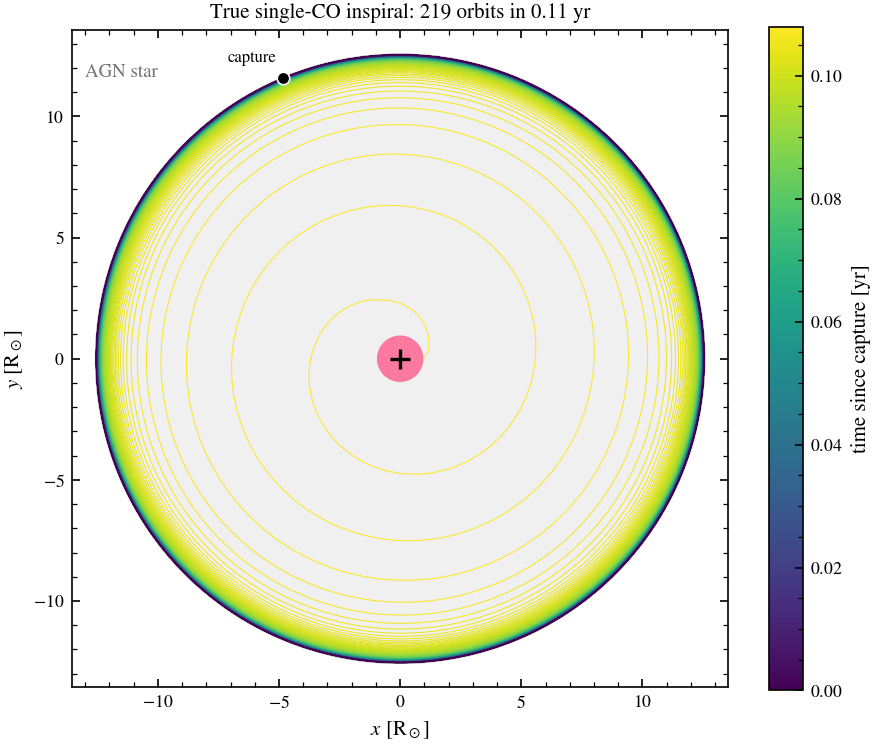

orbits = 219, inspiral time = 0.108 yr


In [2]:
A = caseA_trajectory(model, 10*c.MSUN, model.r_shock)
x, y = A['r']/Rsun * np.cos(A['phi']), A['r']/Rsun * np.sin(A['phi'])
Rstar, rbreak = model.r_shock/Rsun, A['r_final']/Rsun

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.add_patch(plt.Circle((0, 0), Rstar, fc='0.94', ec='0.55', lw=1.3, zorder=0))
ax.add_patch(plt.Circle((0, 0), rbreak, fc=PINK, ec='none', alpha=0.8, zorder=1))
lc = colored_line(ax, x, y, A['t_since']/3.156e7, 'viridis', lw=0.5)
ax.plot(x[-1], y[-1], 'o', color='k', ms=6, mec='w', mew=0.8, zorder=5)   # capture = surface (phase end)
ax.annotate('capture', (x[-1], y[-1]), textcoords='offset points', xytext=(-3, 8), fontsize=8, ha='right')
ax.plot(0, 0, '+', color='k', ms=10, mew=1.6, zorder=4)
ax.text(-0.96*Rstar*1.08, 0.86*Rstar*1.08, 'AGN star', color='0.45', fontsize=9)
L = Rstar*1.08
ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_aspect('equal')
ax.set_xlabel(r'$x$ [R$_\odot$]'); ax.set_ylabel(r'$y$ [R$_\odot$]')
ax.set_title(r'True single-CO inspiral: %.0f orbits in %.2f yr' % (A['N_orb'], A['t_total']/3.156e7))
plt.colorbar(lc, ax=ax, label='time since capture [yr]', shrink=0.85)
plt.tight_layout(); plt.show()
print('orbits = %.0f, inspiral time = %.3f yr' % (A['N_orb'], A['t_total']/3.156e7))

## Case B — the internal BBH orbit

A $10+10\,M_\odot$ binary hardening from $a_{\rm BBH}\sim R_\odot$ to merger (fiducial Model 2).
A spiral is a *poor* representation here: it spans ~4 decades in separation and ~2000 orbits, and
a log-radius spiral crams the final, fast GW plunge into an invisible central knot. What matters is
**where the orbits accumulate**, shown directly below as orbits per decade $dN/d\log_{10}a$.

The behaviour is the **opposite of Case A** and counter-intuitive:
- **Gas drag *weakens* as the binary hardens.** The orbital speed climbs from Mach $\sim$1.4 at
  $R_\odot$ to $\sim$20 near the core, and gravitational drag $\propto\rho/v^2$ falls — $|\dot a|_{\rm gas}$
  drops ~5 orders of magnitude. So the binary *slows down* and piles up orbits as it tightens.
- **GW emission steepens** ($|\dot a|_{\rm GW}\propto a^{-3}$) and takes over below the gas–GW
  crossover at $a\approx4\times10^{-3}R_\odot$, after which the inspiral rushes to merger.

Hence the orbits **peak at the crossover** and then **drop sharply toward merger** — the inspiral
does speed up at the end (the few final orbits), it just isn't visible in a spiral.

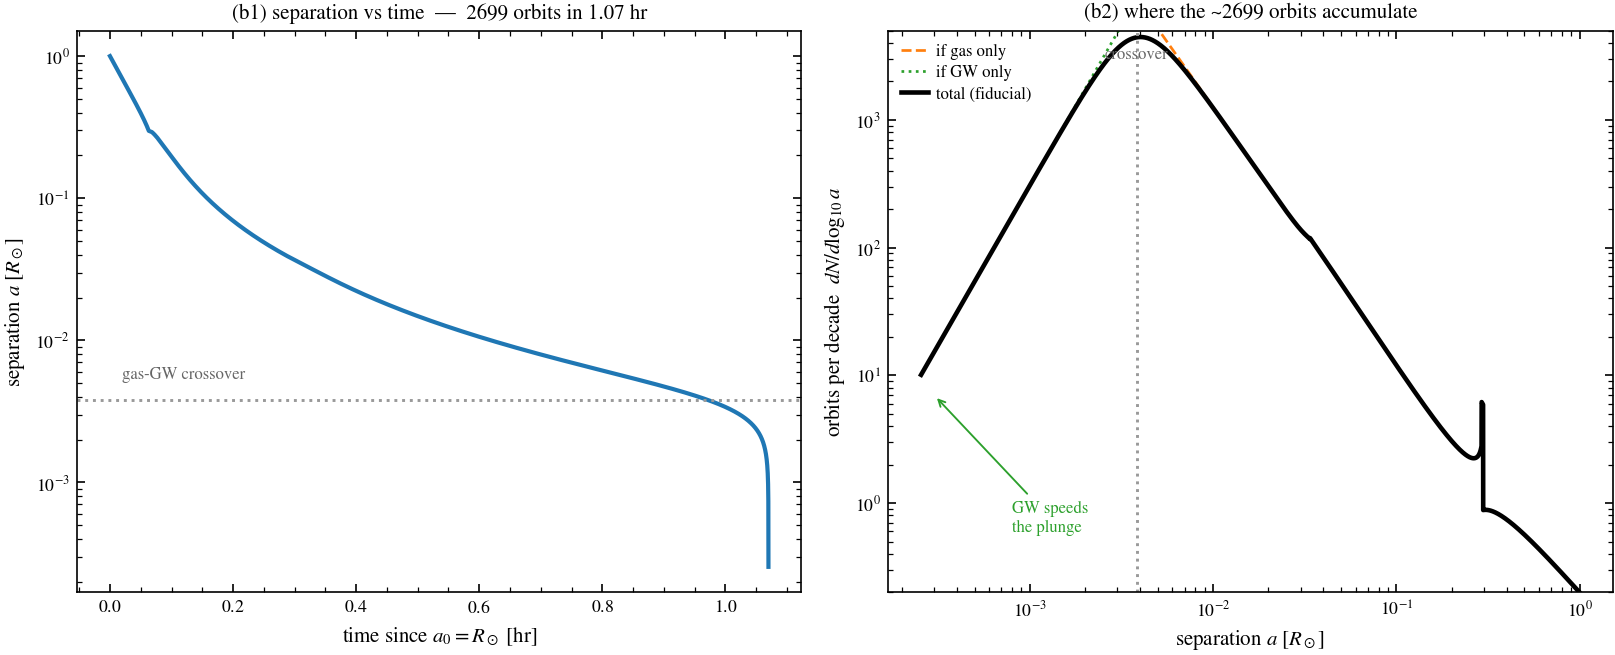

peak 4450 orbits/decade at a=4.0e-03 Rsun (crossover); ~2699 orbits total, merger in 1.07 hr


In [3]:
from scipy.integrate import cumulative_trapezoid as ctz
m1 = m2 = 10*c.MSUN; Mtot = m1 + m2
cs_core = float(model.cs_of_r(model.r[1]))
aend = bbh.a_isco(m1, m2)
a = np.logspace(np.log10(aend), np.log10(c.RSUN), 6000)
dadt_tot, dadt_gw = review.dadt_model(m1, m2, a, model.rho_c, cs_core, model=2)  # fiducial
dadt_gas = dadt_tot - dadt_gw
omega = np.sqrt(G*Mtot/a**3)
t_to_merge = ctz(1.0/np.abs(dadt_tot), a, initial=0.0)            # time from merger up to a
N_total = ctz(omega/np.abs(dadt_tot)/(2*np.pi), a, initial=0.0)[-1]
dNdlog     = np.log(10) * omega * a / np.abs(dadt_tot) / (2*np.pi)  # orbits per decade in a
dNdlog_gas = np.log(10) * omega * a / np.abs(dadt_gas) / (2*np.pi)
dNdlog_gw  = np.log(10) * omega * a / np.abs(dadt_gw)  / (2*np.pi)
a_cross = a[np.argmin(np.abs(np.abs(dadt_gas) - np.abs(dadt_gw)))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
# (b1) separation vs time
ax1.plot((t_to_merge[-1]-t_to_merge)/3600., a/c.RSUN, color='C0', lw=2)
ax1.axhline(a_cross/c.RSUN, color='0.6', ls=':')
ax1.text(0.02, a_cross/c.RSUN*1.4, 'gas-GW crossover', fontsize=8, color='0.4')
ax1.set_yscale('log'); ax1.set_xlabel('time since $a_0=R_\\odot$ [hr]')
ax1.set_ylabel(r'separation $a$ [$R_\odot$]')
ax1.set_title('(b1) separation vs time  —  %.0f orbits in %.2f hr' % (N_total, t_to_merge[-1]/3600.))
# (b2) orbits per decade of separation
ax2.loglog(a/c.RSUN, dNdlog_gas, '--', color='C1', lw=1.3, label='if gas only')
ax2.loglog(a/c.RSUN, dNdlog_gw, ':', color='C2', lw=1.3, label='if GW only')
ax2.loglog(a/c.RSUN, dNdlog, color='k', lw=2.2, label='total (fiducial)')
ax2.axvline(a_cross/c.RSUN, color='0.6', ls=':')
ax2.text(a_cross/c.RSUN, 3e3, 'crossover', fontsize=8, color='0.4', ha='center')
ax2.annotate('GW speeds\nthe plunge', xy=(3e-4, 7), xytext=(8e-4, 0.6),
             fontsize=8, color='C2', arrowprops=dict(arrowstyle='->', color='C2', lw=0.9))
ax2.set_xlabel(r'separation $a$ [$R_\odot$]'); ax2.set_ylabel(r'orbits per decade  $dN/d\log_{10}a$')
ax2.set_ylim(0.2, 5e3); ax2.legend(fontsize=8, loc='upper left')
ax2.set_title('(b2) where the ~%.0f orbits accumulate' % N_total)
plt.tight_layout(); plt.show()
print('peak %.0f orbits/decade at a=%.1e Rsun (crossover); ~%.0f orbits total, merger in %.2f hr'
      % (dNdlog.max(), a[np.argmax(dNdlog)]/c.RSUN, N_total, t_to_merge[-1]/3600.))

## Both inspirals together — Fig. 3 with the real trajectories

The real-trajectory analog of the schematic Fig. 3.

**(a)** A single compact object spiralling through the star (linear radius — true geometry). It
orbits the *enclosed stellar mass* $M_{\rm enc}(r)$, so it lingers near the surface (where the gas is
tenuous and the orbit is deeply bound to ~the whole star) and then plunges through the dense interior.

**(b)** *Exactly the same situation as (a), but with a second black hole (BH1) pinned at the centre*
(log radius, so the whole star down to merger is visible). BH2 orbits the enclosed stellar mass
*plus* BH1, $M_{\rm enc}(r)+m_1$, at the local gas density $\rho(r)$ — identical drag physics to (a) —
so it likewise lingers just under the surface (the black circle) before sinking. The gravitational-wave
luminosity is that of the BH2-BH1 pair, which only takes over once $M_{\rm enc}(r)<m_1$ deep in the core.
The pink disk marks where the point-perturber / static-background treatment fails — BH2's Bondi radius
exceeds its orbital radius, $R_{\rm BHL}/r>1$ (here $r\lesssim0.6\,R_\odot$, essentially where the two BHs
become a genuine binary) — so the final hardening to merger requires a 3D, self-gravitating calculation.
The two panels use different radial scalings (single-CO inspiral ~1 decade; the central-BH case spans
the full ~4.7 decades from the surface to the ISCO).

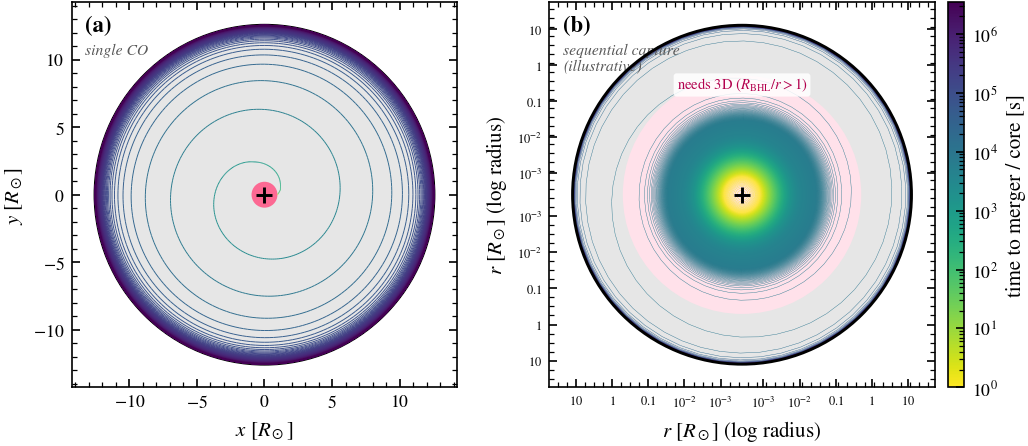

In [4]:
# Fig. 3 exactly as used in the paper. To keep this notebook in sync with the manuscript,
# we call the packaged figure function (gray stellar interior, pink 3D-breakdown disks,
# colour = log time-to-merger/core in seconds). Source: agn_cee/review.py::fig_true_trajectories
fig = review.fig_true_trajectories(model)
fig.savefig('fig3_true_trajectories.pdf')
plt.show()

## Where the orbits accumulate — publication figure

A single-panel, paper-styled version. The **total** (solid) peaks at the gas–GW crossover
(~$4\times10^{-3}\,R_\odot$): that is where the ~2700 orbits pile up. Left of it the inspiral is
**GW-dominated** (the plunge); right of it it is **gas-drag-dominated**. The dashed/dotted branches
show what each channel *alone* would give. The kink near $0.3\,R_\odot$ is the **transonic transition**
(per-component Mach $=1$), where gaseous dynamical friction peaks (Ostriker 1999). Tweak freely and
re-run; the cell writes `figures/fig_orbit_accumulation.pdf`.

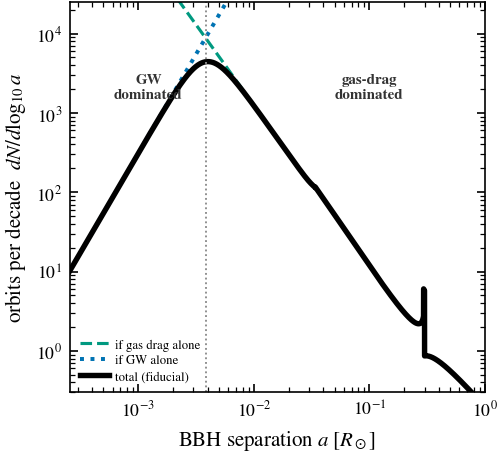

N_total=2689, crossover=3.83e-03 Rsun, peak=4434 orb/dec; kink at ~0.3 Rsun = per-component Mach 1 (transonic)


In [5]:
# === Where the orbits accumulate (publication figure) ===
from agn_cee import plotstyle
from agn_cee.plotstyle import COLORS as C, COL
plotstyle.apply()                                  # paper rcParams (styles plt below)
m1 = m2 = 10*c.MSUN; M = m1 + m2
cs = review.cs_at(review.sound_speed_prescriptions(), 0.5*Rsun, "cs_gas")   # paper-fiducial c_s
a = np.logspace(np.log10(bbh.a_isco(m1, m2)), np.log10(Rsun), 6000)
dadt_tot, dadt_gw = review.dadt_model(m1, m2, a, model.rho_c, cs, model=2)  # fiducial (Model 2)
dadt_gas = dadt_tot - dadt_gw
omega = np.sqrt(G*M/a**3)
dNdlog     = np.log(10)*omega*a/np.abs(dadt_tot)/(2*np.pi)                   # orbits per decade
dNdlog_gas = np.log(10)*omega*a/np.abs(dadt_gas)/(2*np.pi)
dNdlog_gw  = np.log(10)*omega*a/np.abs(dadt_gw )/(2*np.pi)
N_total = ctz(omega/np.abs(dadt_tot)/(2*np.pi), a, initial=0.0)[-1]
a_cross = a[np.argmin(np.abs(np.abs(dadt_gas)-np.abs(dadt_gw)))]

fig, ax = plt.subplots(figsize=(COL, 3.1)); ar = a/Rsun; xc = a_cross/Rsun
ax.loglog(ar, dNdlog_gas, ls="--", color=C[1], lw=1.5, label="if gas drag alone")
ax.loglog(ar, dNdlog_gw,  ls=":",  color=C[6], lw=1.9, label="if GW alone")
ax.loglog(ar, dNdlog,     color="k", lw=2.6, label="total (fiducial)")
ax.axvline(xc, color="0.55", ls=(0, (1, 1.5)), lw=0.9)               # gas-GW crossover
ax.set_xlim(ar.min(), 1.0); ax.set_ylim(0.3, 2.5e4)
ax.text(xc*0.32, 2.1e3, "GW\ndominated",       color="0.2", fontsize=7.2, ha="center", va="center", fontweight="bold")
ax.text(xc*26,   2.1e3, "gas-drag\ndominated", color="0.2", fontsize=7.2, ha="center", va="center", fontweight="bold")
ax.legend(fontsize=6.1, loc="lower left", handlelength=2.3, borderaxespad=0.4)
ax.set_xlabel(r"BBH separation $a$ [$R_\odot$]")
ax.set_ylabel(r"orbits per decade  $dN/d\log_{10}a$")
fig.tight_layout(pad=0.4)
fig.savefig("figures/fig_orbit_accumulation.pdf")
plt.show()
print("N_total=%.0f, crossover=%.2e Rsun, peak=%.0f orb/dec; kink at ~0.3 Rsun = per-component Mach 1 (transonic)"
      % (N_total, a_cross/Rsun, dNdlog.max()))